# **VI) Descriptive Statistics**

Statistical analysis of the transformed dataset by generating descriptive summaries, correlations,
and non-parametric regime tests to assess how Bitcoin returns and volatility shift under different monetary policy environments.

1. [**Import Data**](#1-import--data)
2. [**Descriptive Statistics**](#2-descriptive-statistics)
3. [**Correlation Analysis**](#3-correlation-analysis)
4. [**Time-Series Evolution**](#4-time-series-evolution)
5. [**Regime Analysis**](#5-regime-analysis)
6. [**Regime Statistical Significance**](#6-statistical-significance)


### **1) Import Data** <a id="1-import--data"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import skew, kurtosis, kruskal, levene

df = pd.read_csv("data/All_Data_Weekly_transformed.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

### **2) Descriptive Statistics** <a id="2-descriptive-statistics"></a>

In [2]:
# Descriptive Table Function
def descriptive_table(df: pd.DataFrame) -> pd.DataFrame:
    desc = pd.DataFrame(index=df.columns)
    desc["Mean"] = df.mean()
    desc["SD"]   = df.std()
    desc["Skew"] = df.apply(lambda x: skew(x.dropna()))
    desc["Kurt"] = df.apply(lambda x: kurtosis(x.dropna(), fisher=False))
    desc["Min"]  = df.min()
    desc["5%"]   = df.quantile(0.05)
    desc["25%"]  = df.quantile(0.25)
    desc["Med"]  = df.median()
    desc["75%"]  = df.quantile(0.75)
    desc["95%"]  = df.quantile(0.95)
    desc["Max"]  = df.max()
    desc["n"]    = df.count()
    return desc

# Variable Mapping
names = {
    "btc_ret": "Btc", "mp_exp": "MPE", 
    "news_sent": "NewsSent", "policy_risk_gr": "PolUncert",
    "sp500_ret": "SP500", "brent_gr": "Brent", 
    "gold_ret": "Gold", "hy_ret": "HighYield",
    "gpr_gr": "GeopolRisk", "vix_gr": "VIX", "dxy_gr": "USDollar",
    "emv": "Infect",
    "claims_dlog": "JoblessClaim", "eer_dlog": "ExchRate", 
    "ffr": "FFR", "infl5y": "5yInflExp",
    "gt_infl": "GgleInfl", "gt_recess": "GgleReces", "gt_climate": "GgleClimate",
}

desc_stats = descriptive_table(df[list(names.keys())])

# Display
desc_display = desc_stats.rename(index=names)
display(desc_display.round(2))

# Create the LaTeX index: "Academic Name (\texttt{code\_name})"
desc_tex = desc_stats.copy()
desc_tex.index = [f"{names[v]}" for v in desc_tex.index]

# LaTeX italics formatting
desc_tex.index = [f"\\textit{{{name}}}" for name in desc_tex.index]


# LaTeX
latex_table = desc_tex.to_latex(
    na_rep="",
    float_format="%.2f",
    column_format="l" + "c" * desc_tex.shape[1],
    escape=False, # Crucial: allows LaTeX commands in index
    caption="Descriptive Statistics of Model Variables",
    label="tab:desc_stats",
)

print(latex_table)

,Mean,SD,Skew,Kurt,Min,5%,25%,Med,75%,95%,Max,n
Btc,0.01,0.10,-0.36,4.79,-0.41,-0.15,-0.03,0.01,0.06,0.16,0.35,545
MPE,-0.03,0.09,-1.37,13.56,-0.62,-0.21,-0.05,-0.01,0.01,0.06,0.53,546
NewsSent,-0.00,0.18,-1.20,5.09,-0.66,-0.34,-0.09,0.03,0.11,0.24,0.32,546
PolUncert,0.05,0.34,1.75,8.71,-0.57,-0.36,-0.17,-0.01,0.18,0.69,2.14,545
SP500,0.00,0.02,-0.89,10.40,-0.16,-0.03,-0.01,0.00,0.02,0.03,0.11,545
Brent,0.00,0.05,0.36,9.28,-0.25,-0.08,-0.03,0.00,0.03,0.08,0.37,545
Gold,0.00,0.02,-0.06,4.65,-0.09,-0.03,-0.01,0.00,0.01,0.03,0.08,545
HighYield,0.00,0.01,-2.15,29.91,-0.10,-0.01,-0.00,0.00,0.00,0.01,0.05,545
GeopolRisk,0.03,0.27,2.20,15.02,-0.50,-0.31,-0.14,-0.01,0.16,0.46,2.08,545
VIX,0.01,0.18,2.06,12.96,-0.43,-0.20,-0.08,-0.01,0.08,0.33,1.35,545


\begin{table}
\caption{Descriptive Statistics of Model Variables}
\label{tab:desc_stats}
\begin{tabular}{lcccccccccccc}
\toprule
 & Mean & SD & Skew & Kurt & Min & 5% & 25% & Med & 75% & 95% & Max & n \\
\midrule
\textit{Btc} & 0.01 & 0.10 & -0.36 & 4.79 & -0.41 & -0.15 & -0.03 & 0.01 & 0.06 & 0.16 & 0.35 & 545 \\
\textit{MPE} & -0.03 & 0.09 & -1.37 & 13.56 & -0.62 & -0.21 & -0.05 & -0.01 & 0.01 & 0.06 & 0.53 & 546 \\
\textit{NewsSent} & -0.00 & 0.18 & -1.20 & 5.09 & -0.66 & -0.34 & -0.09 & 0.03 & 0.11 & 0.24 & 0.32 & 546 \\
\textit{PolUncert} & 0.05 & 0.34 & 1.75 & 8.71 & -0.57 & -0.36 & -0.17 & -0.01 & 0.18 & 0.69 & 2.14 & 545 \\
\textit{SP500} & 0.00 & 0.02 & -0.89 & 10.40 & -0.16 & -0.03 & -0.01 & 0.00 & 0.02 & 0.03 & 0.11 & 545 \\
\textit{Brent} & 0.00 & 0.05 & 0.36 & 9.28 & -0.25 & -0.08 & -0.03 & 0.00 & 0.03 & 0.08 & 0.37 & 545 \\
\textit{Gold} & 0.00 & 0.02 & -0.06 & 4.65 & -0.09 & -0.03 & -0.01 & 0.00 & 0.01 & 0.03 & 0.08 & 545 \\
\textit{HighYield} & 0.00 & 0.01 & -2.15 & 29.

### **3) Correlation Analysis** <a id="3-correlation-analysis"></a>

In [3]:
predictors = [
    "btc_ret", "mp_exp", "news_sent", "policy_risk_gr",
    "sp500_ret", "brent_gr", "gold_ret", "hy_ret",
    "gpr_gr", "vix_gr", "dxy_gr", "emv",
    "claims_dlog", "eer_dlog", "ffr", "infl5y",
    "gt_infl", "gt_recess", "gt_climate"
]

def latex_texttt(s: str) -> str:
    return rf"\texttt{{{s.replace('_', r'\_')}}}"

# Compute and Mask Correlation
corr = df[predictors].corr()
corr = corr.iloc[1:, :-1]
mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
corr_lower = corr.mask(mask).round(2)

# Rename Index and Columns for display/LaTeX
# Rows get Academic Names, Columns get LaTeX \texttt code names
corr_lower = corr_lower.rename(index=names, columns=names)
display(corr_lower)

# LaTeX
corr_tex = corr_lower.copy()

latex_table = corr_tex.to_latex(
    na_rep="",
    float_format="%.2f",
    column_format="l" + "c" * corr_lower.shape[1],
    escape=True
)

print(latex_table)

,Btc,MPE,NewsSent,PolUncert,SP500,Brent,Gold,HighYield,GeopolRisk,VIX,USDollar,Infect,JoblessClaim,ExchRate,FFR,5yInflExp,GgleInfl,GgleReces
MPE,0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NewsSent,0.02,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PolUncert,-0.07,0.06,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SP500,0.18,0.11,-0.07,-0.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brent,0.12,-0.08,-0.06,-0.07,0.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gold,0.08,0.01,-0.03,0.05,0.12,0.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HighYield,0.15,0.11,-0.06,-0.09,0.75,0.35,0.21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GeopolRisk,-0.00,-0.01,0.02,0.01,-0.01,0.02,0.10,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VIX,-0.19,-0.03,0.10,0.09,-0.73,-0.27,0.04,-0.42,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
USDollar,-0.08,-0.05,0.05,0.03,-0.28,-0.09,-0.49,-0.36,0.02,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


\begin{tabular}{lcccccccccccccccccc}
\toprule
 & Btc & MPE & NewsSent & PolUncert & SP500 & Brent & Gold & HighYield & GeopolRisk & VIX & USDollar & Infect & JoblessClaim & ExchRate & FFR & 5yInflExp & GgleInfl & GgleReces \\
\midrule
MPE & 0.05 &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
NewsSent & 0.02 & 0.04 &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
PolUncert & -0.07 & 0.06 & 0.02 &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
SP500 & 0.18 & 0.11 & -0.07 & -0.05 &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
Brent & 0.12 & -0.08 & -0.06 & -0.07 & 0.30 &  &  &  &  &  &  &  &  &  &  &  &  &  \\
Gold & 0.08 & 0.01 & -0.03 & 0.05 & 0.12 & 0.09 &  &  &  &  &  &  &  &  &  &  &  &  \\
HighYield & 0.15 & 0.11 & -0.06 & -0.09 & 0.75 & 0.35 & 0.21 &  &  &  &  &  &  &  &  &  &  &  \\
GeopolRisk & -0.00 & -0.01 & 0.02 & 0.01 & -0.01 & 0.02 & 0.10 & 0.00 &  &  &  &  &  &  &  &  &  &  \\
VIX & -0.19 & -0.03 & 0.10 & 0.09 & -0.73 & -0.27 & 0.04 & -0.42 & 0.02 &  &  &  &  &  &  & 

### **4) Time-Series Evolution** <a id="4-time-series-evolution"></a>

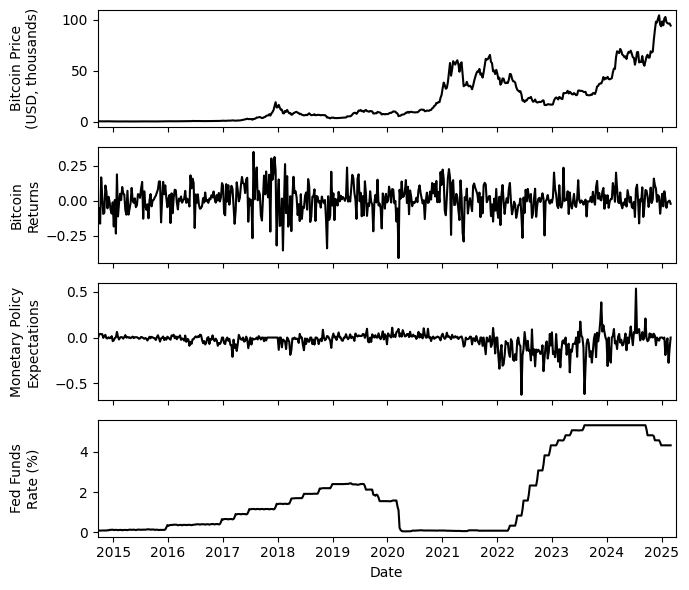

In [4]:
df.index = pd.to_datetime(df.index)

fig, axes = plt.subplots(
    4, 1,
    sharex=True,
    figsize=(7, 6)
)

# Bitcoin Price (scaled)
axes[0].plot(df.index, df["btc"] / 1000, color="black")
axes[0].set_ylabel("Bitcoin Price\n(USD, thousands)")

# Bitcoin Returns
axes[1].plot(df.index, df["btc_ret"], color="black")
axes[1].set_ylabel("Bitcoin\nReturns")

# Monetary Policy Expectations
axes[2].plot(df.index, df["mp_exp"], color="black")
axes[2].set_ylabel("Monetary Policy\nExpectations")

# Effective Federal Funds Rate
axes[3].plot(df.index, df["ffr"], color="black")
axes[3].set_ylabel("Fed Funds\nRate (%)")
axes[3].set_xlabel("Date")

# Apply x-axis limits
axes[3].set_xlim(pd.to_datetime("2014-09-19"),
                 pd.to_datetime("2025-04-04"))

plt.subplots_adjust(hspace=0.15)

fig.align_ylabels(axes)
plt.tight_layout()
plt.savefig("figures/plot_main_var_evol.pdf")
plt.show()


### **5) Regime Analysis**  <a id="5-regime-analysis"></a>

Categorizes market environments into Dovish/Hawkish (Policy Expectations) and Rising/Falling (Interest Rates).

Bitcoin Returns by Monetary Policy Expectations


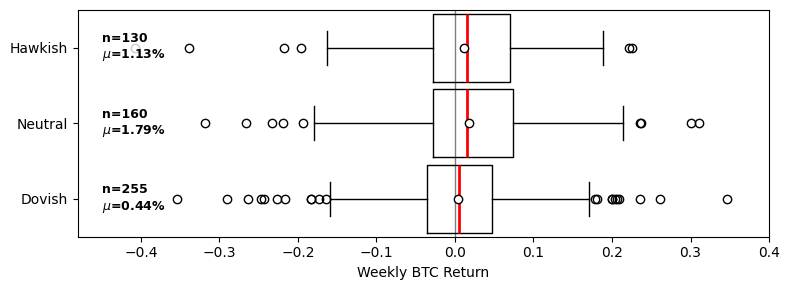

Bitcoin Returns by Fed Funds Rate Direction


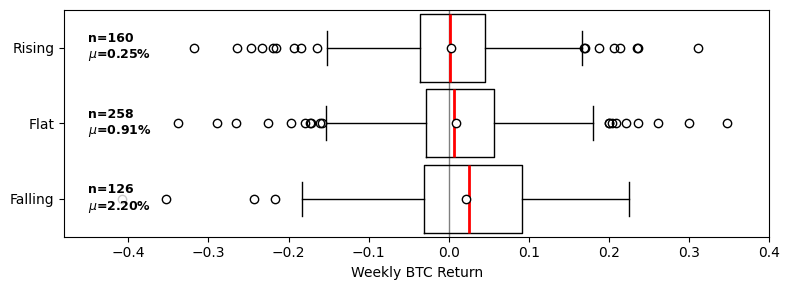

In [5]:
d = df[["btc_ret", "mp_exp", "ffr"]].dropna().copy()

# Regimes logic
d["mp_regime"] = pd.cut(d["mp_exp"], bins=[-np.inf, -0.01, 0.01, np.inf], 
                        labels=["Dovish", "Neutral", "Hawkish"], include_lowest=True)

d["ffr_regime"] = pd.cut(d["ffr"].diff(), bins=[-np.inf, -1e-12, 1e-12, np.inf], 
                         labels=["Falling", "Flat", "Rising"], include_lowest=True)

d["btc_ret_plot"] = d["btc_ret"]

# Plot function
def draw_single_horizontal_plot(data, group_col):
    plt.figure(figsize=(8, 3))
    ax = plt.gca()
    
    order = data[group_col].cat.categories
    labels = [g for g in order if g in data[group_col].unique()]
    arrays = [data.loc[data[group_col] == g, "btc_ret_plot"].dropna().values for g in labels]

    ax.boxplot(arrays, 
               tick_labels=labels, 
               vert=False, 
               widths=0.9, 
               showmeans=True, 
               meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"},
               medianprops={'color': 'red', 'linewidth': 2}) # RED median line
    
    ax.axvline(0.0, color='black', linewidth=1, alpha=0.5)
    ax.set_xlim(-0.48, 0.4)
    ax.set_xlabel("Weekly BTC Return")

    # Placement of stats: Far left edge
    for i, g in enumerate(labels, start=1):
        n = int((data[group_col] == g).sum())
        mu = data.loc[data[group_col] == g, "btc_ret_plot"].mean()
        
        # fr"..." (Raw F-string) prevents the SyntaxWarning for \mu
        ax.text(-0.45, i, fr"n={n}" + "\n" + fr"$\mu$={mu:.2%}", 
                ha="left", va="center", fontsize=9, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        
# PLOT 1: Monetary Policy Expectations
print("Bitcoin Returns by Monetary Policy Expectations")
draw_single_horizontal_plot(
    d.dropna(subset=["mp_regime"]), 
    "mp_regime"
)
plt.tight_layout()
plt.savefig("figures/btc_ret_monetary.pdf")
plt.show()

# PLOT 2: FFR Direction
print("Bitcoin Returns by Fed Funds Rate Direction")
draw_single_horizontal_plot(
    d.dropna(subset=["ffr_regime"]), 
    "ffr_regime"
)
plt.tight_layout()
plt.savefig("figures/btc_ret_ffr.pdf")
plt.show()

### **6) Regime Statistical Significance**  <a id="6-statistical-significance"></a>

Performs non-parametric tests to confirm if the differences in medians (Kruskal-Wallis) and variances (Levene) are statistically significant.

In [6]:
def get_regime_stats(data, group_col, target_col="btc_ret"):
# Using observed=True to handle categorical data and avoid FutureWarnings
    groups = [data.loc[data[group_col] == g, target_col].dropna() for g in data[group_col].cat.categories]
    
    # Kruskal-Wallis (Median) and Levene's (Volatility) tests
    h_stat, p_kruskal = kruskal(*groups)
    l_stat, p_levene = levene(*groups)
    
    # Tail Risk (5th percentile) 
    q5_vals = data.groupby(group_col, observed=True)[target_col].quantile(0.05)
    
    results = {
        "Variable": group_col,
        "Kruskal H": h_stat,
        "p-val (Med)": p_kruskal,
        "Levene W": l_stat,
        "p-val (Vol)": p_levene,
        "Max Tail Risk (q5)": q5_vals.min() 
    }
    return results

# 1. Monetary Policy
stats_mp = get_regime_stats(d.dropna(subset=["mp_regime"]), "mp_regime")

# 2. FFR
stats_ffr = get_regime_stats(d.dropna(subset=["ffr_regime"]), "ffr_regime")

df_stats = pd.DataFrame([stats_mp, stats_ffr])
display(df_stats)

# Print LaTeX
mapping = {"mp_regime": "MPE", "ffr_regime": "FFR"}
df_stats["Variable"] = df_stats["Variable"].replace(mapping)
cols_to_keep = ["Variable", "Kruskal H", "p-val (Med)", "Levene W", "p-val (Vol)", "Max Tail Risk (q5)"]
df_stats = df_stats[cols_to_keep]

latex_table = df_stats.to_latex(
    index=False,
    float_format="%.4f",
    column_format="lccccc",
    caption="Non-parametric and Variance Tests across Regimes",
    label="tab:regime_tests",
    escape=False
)

print(latex_table)

,Variable,Kruskal H,p-val (Med),Levene W,p-val (Vol),Max Tail Risk (q5)
0,mp_regime,2.704477,0.258661,0.920439,0.398966,-0.152879
1,ffr_regime,5.454021,0.065415,2.677942,0.069615,-0.164901


\begin{table}
\caption{Non-parametric and Variance Tests across Regimes}
\label{tab:regime_tests}
\begin{tabular}{lccccc}
\toprule
Variable & Kruskal H & p-val (Med) & Levene W & p-val (Vol) & Max Tail Risk (q5) \\
\midrule
MPE & 2.7045 & 0.2587 & 0.9204 & 0.3990 & -0.1529 \\
FFR & 5.4540 & 0.0654 & 2.6779 & 0.0696 & -0.1649 \\
\bottomrule
\end{tabular}
\end{table}

